In [1]:
"""
SIF regional evaluation
@L. Leverne/F. Maignan/V. Tartaglione
"""

#import
import pandas as pd
import os
import sys
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors
import matplotlib.cm as cm
import numpy as np
import glob
import math
import xarray as xr
import netCDF4
import seaborn as sns
from scipy.stats import linregress

In [2]:
### fonctions
def rmse(observation, prediction):
    RMSE = math.sqrt(np.nanmean((np.array(observation)-np.array(prediction))**2))
    RMSE = round(RMSE,3)
    return RMSE

In [3]:
def rmse_weighted(observation, prediction,weights):
    RMSE = math.sqrt(np.nansum(((np.array(observation)-np.array(prediction))**2)*weights)/np.sum(weights))
    return RMSE

In [4]:
def bias(prediction,observation):
    bias = (prediction - observation).mean()
    bias = round(bias,3)
    return bias

In [5]:
def amplitude(data):
    amp = np.max(data)-np.min(data)
    amp = round(amp,2)
    return amp

In [6]:
def sif_simu(path,mask_array):
    data = xr.open_dataset(path,decode_times ='False')
    data.coords['mask'] = (mask_array)
    sif=data['SIF_2fluxRTM_FM']
    contfrac=data['Contfrac'].to_numpy()
    areas=data['Areas']
    #masquage (->nan values)
    areas=areas.where(mask_array==2)
    areas=areas.to_numpy()
    #multiplication by contfrac
    sif_total=np.sum(sif,axis=1)*contfrac
    sif_bacour = sif_total.where(sif_total.mask == 2)
    tstep = pd.date_range(start=years+'-01-01', periods=12, freq='M')
    sif_bacour['time_counter'] = tstep
    sif_final = sif_bacour.drop(['time_centered','mask'])
    return sif_final 

In [7]:
#https://stackoverflow.com/questions/62592803/xarray-equivalent-of-np-reshape
def xr_reshape(A, dim, newdims, coords):
    """ Reshape DataArray A to convert its dimension dim into sub-dimensions given by
    newdims and the corresponding coords.
    Example: Ar = xr_reshape(A, 'time', ['year', 'month'], [(2017, 2018), np.arange(12)]) """

    # Create a pandas MultiIndex from these labels
    ind = pd.MultiIndex.from_product(coords, names=newdims)

    # Replace the time index in the DataArray by this new index,
    A1 = A.copy()

    A1.coords[dim] = ind

    # Convert multiindex to individual dims using DataArray.unstack().
    # This changes dimension order! The new dimensions are at the end.
    A1 = A1.unstack(dim)

    # Permute to restore dimensions
    i = A.dims.index(dim)
    dims = list(A1.dims)

    for d in newdims[::-1]:
        dims.insert(i, d)

    for d in newdims:
        _ = dims.pop(-1)


    return A1.transpose(*dims)

In [8]:
def filter_sites(data):
    return data[~data['remarques'].str.contains('eviter|éviter', case=False, na=False)]

In [9]:
# Function to calculate years for a site with prioritization
def calculate_prioritized_years(row):
    priority_order = ['warmwinter2020', 'fluxnet2015', 'fluxnet2007']
    for dataset in priority_order:
        start_col = f'year_{dataset}'
        if pd.notna(row[start_col]):
            start_year, end_year = map(int, row[start_col].split('-'))
            return end_year + 1 - start_year
    return 0

In [10]:
def calculate_years(year_ranges):
    total_years = 0
    for year_range in year_ranges.split('+'):
        start, end = map(int, year_range.split('-'))
        total_years += end + 1 - start
    return total_years

In [11]:
def get_site_category(site_id):
    if site_id in assimilation_sites:
        return 'Assimilation', colors[0]  # First color from colorblind palette
    elif site_id in evaluation_sites:
        return 'Evaluation', colors[3]  # Second color from colorblind palette
    else:
        return None, None

In [12]:
# IBM ColorBlind Safe palette
ibm_colors = [
        '#648FFF', '#785EF0', '#DC267F', '#FE6100', '#FFB000',
        '#009E73', '#56B4E9', '#E69F00', '#CC79A7', '#005AB5',
        '#F0E442', '#E6AB02', '#00A087', '#882255', '#AA4499'
    ]

## initialisations
list_pft =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/ARCHIVE/IGCM_OUT/OL2/DEVT/secsto/REGIONAL.PFT7.PRIOR.GDD/SBG/Output/MO/REGIONAL.PFT7.PRIOR.GDD_20*stomate_history.nc'))
list_bacour =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/ARCHIVE/IGCM_OUT/OL2/DEVT/secsto/REGIONAL.PFT7.PRIOR.GDD/SRF/Output/MO/REGIONAL.PFT7.PRIOR.GDD_20*sechiba_history.nc'))
list_optsif =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/ARCHIVE/IGCM_OUT/OL2/DEVT/secsto/REGIONAL.PFT7.SIFONLY.GDD/SRF/Output/MO/REGIONAL.PFT7.SIFONLY.GDD_20*sechiba_history.nc'))
list_raczka =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/ARCHIVE/IGCM_OUT/OL2/DEVT/secsto/REGIONAL.PFT7.SIFGPP.GDD/SRF/Output/MO/REGIONAL.PFT7.SIFGPP.GDD_20*sechiba_history.nc'))
list_optgpp =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/ARCHIVE/IGCM_OUT/OL2/DEVT/secsto/REGIONAL.PFT7.GPPONLY.GDD/SRF/Output/MO/REGIONAL.PFT7.GPPONLY.GDD_20*sechiba_history.nc'))
list_bacouropt =sorted(glob.glob('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Vincent_NPQ/ARCHIVE/IGCM_OUT/OL2/DEVT/secsto/REGIONAL.PFT7.SIFGPP.BACOUR.GDD/SRF/Output/MO/REGIONAL.PFT7.SIFGPP.BACOUR.GDD_20*sechiba_history.nc'))

First_YEAR_simus=2000
First_YEAR_SIF=2018
list_pft = list_pft[First_YEAR_SIF-First_YEAR_simus:]
list_bacour = list_bacour[First_YEAR_SIF-First_YEAR_simus:]
list_optsif = list_optsif[First_YEAR_SIF-First_YEAR_simus:]
list_raczka = list_raczka[First_YEAR_SIF-First_YEAR_simus:]
list_optgpp = list_optgpp[First_YEAR_SIF-First_YEAR_simus:]
list_bacouropt = list_bacouropt[First_YEAR_SIF-First_YEAR_simus:]

list_years = np.arange(First_YEAR_SIF,2021)

dt_GPP_tot =pd.DataFrame()

obs_nY = []
bacour_nY = []
raczka_nY = []
tot_raczka = []
tot_bacour = []
tot_bacouropt = []
tot_optgpp =[]
tot_optsif =[]
tot_tair =[]

seuil=0.5

In [13]:
#Read data 
obs = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_obs_200122.nc')
obs = obs[['lat','lon','record','SIF_Corr_743']]
obs = obs.rename_dims({'record':'time_counter'})
obs = obs.rename({'record':'time_counter'})

bacour = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_prior_200122.nc')
raczka = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_raczka_200122.nc')
optsif = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_optsif_200122.nc')
optgpp = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_optgpp_200122.nc')
bacouropt = xr.open_dataset('/home/satellites2/maignan/ORCHIDEE/TESTS/test_Lucas/MAP_data_EVALUATION_'+str(seuil)+'/sif_bacouropt_200122.nc')

obs = obs.sel(time_counter=slice("2018-05-01", "2020-12-31"))
bacour = bacour.sel(time_counter=slice("2018-05-01", "2020-12-31"))
raczka = raczka.sel(time_counter=slice("2018-05-01", "2020-12-31"))
optsif = optsif.sel(time_counter=slice("2018-05-01", "2020-12-31"))
optgpp = optgpp.sel(time_counter=slice("2018-05-01", "2020-12-31"))
bacouropt = bacouropt.sel(time_counter=slice("2018-05-01", "2020-12-31"))

/tmp/ipykernel_1628/2494611795.py:5: UserWarning: rename 'record' to 'time_counter' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  obs = obs.rename({'record':'time_counter'})


In [14]:
#Setting negative SIF observations to zero
mask_negative = obs['SIF_Corr_743'] < 0
obs['SIF_Corr_743'] = obs['SIF_Corr_743'].where(~mask_negative, 0)
#print((obs.SIF_Corr_743<0).sum())

In [15]:
#Masking to keep common grid cells
mask = np.isnan(obs.SIF_Corr_743) | np.isnan(bacour.SIF_2fluxRTM_FM) 
obs['SIF_Corr_743'] = xr.where(mask,np.nan,obs.SIF_Corr_743)
bacour['SIF_2fluxRTM_FM'] = xr.where(mask,np.nan,bacour.SIF_2fluxRTM_FM)
raczka['SIF_2fluxRTM_FM'] = xr.where(mask,np.nan,raczka.SIF_2fluxRTM_FM)
optsif['SIF_2fluxRTM_FM'] = xr.where(mask,np.nan,optsif.SIF_2fluxRTM_FM)
optgpp['SIF_2fluxRTM_FM'] = xr.where(mask,np.nan,optgpp.SIF_2fluxRTM_FM)
bacouropt['SIF_2fluxRTM_FM'] = xr.where(mask,np.nan,bacouropt.SIF_2fluxRTM_FM)

In [16]:
### Mean seasonal cycles
obs_sav = obs.copy()
bacour_sav = bacour.copy()
raczka_sav = raczka.copy()
optsif_sav = optsif.copy()
optgpp_sav = optgpp.copy()
bacouropt_sav = bacouropt.copy()

obs = obs.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
obs_std = obs_sav.groupby('time_counter.month').std(dim=['time_counter','lat','lon'])
obs_q1 = obs_sav.groupby('time_counter.month').quantile(0.25,dim=['time_counter','lat','lon'])
obs_q3 = obs_sav.groupby('time_counter.month').quantile(0.75,dim=['time_counter','lat','lon'])
obs = pd.DataFrame(data={'time':obs.month,'SIF': obs.SIF_Corr_743,'std': obs_std.SIF_Corr_743,'q1': obs_q1.SIF_Corr_743,'q3': obs_q3.SIF_Corr_743})
bacour = bacour.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
bacour = pd.DataFrame(data={'time':bacour.month,'SIF': bacour.SIF_2fluxRTM_FM})
raczka = raczka.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
raczka = pd.DataFrame(data={'time':raczka.month,'SIF': raczka.SIF_2fluxRTM_FM})
optsif = optsif.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
optsif = pd.DataFrame(data={'time':optsif.month,'SIF': optsif.SIF_2fluxRTM_FM})
optgpp = optgpp.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
optgpp = pd.DataFrame(data={'time':optgpp.month,'SIF': optgpp.SIF_2fluxRTM_FM})
bacouropt = bacouropt.groupby('time_counter.month').mean(dim=['time_counter','lat','lon'])
bacouropt = pd.DataFrame(data={'time':bacouropt.month,'SIF': bacouropt.SIF_2fluxRTM_FM})

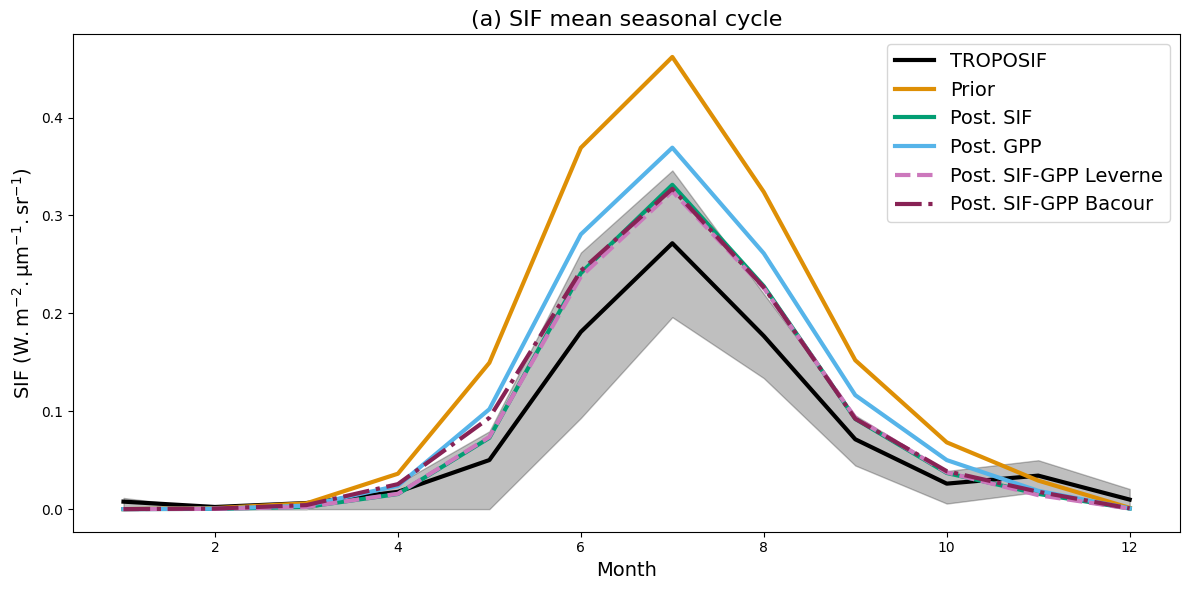

In [17]:
if True:
    #Plot
    fontsize_title=16
    fontsize_label=14
    fontsize_legend=14
    
    taille_trait=3

    fig, ax = plt.subplots(figsize=(12,6))
    plt.plot(obs['time'], obs['SIF'], color='#000000',      label='TROPOSIF',linewidth=taille_trait)
    plt.fill_between(obs['time'], obs['q1'], obs['q3'],
        alpha=0.25, edgecolor='#000000', facecolor='#000000')
        
    plt.plot(bacour['time'], bacour['SIF'], color=sns.color_palette("colorblind")[1],label='Prior',linewidth=taille_trait)
    plt.plot(optsif['time'], optsif['SIF'], color=sns.color_palette("colorblind")[2],label='Post. SIF',linewidth=taille_trait)
    plt.plot(optgpp['time'], optgpp['SIF'], color=sns.color_palette("colorblind")[-1],label='Post. GPP',linewidth=taille_trait)
    plt.plot(raczka['time'], raczka['SIF'], color=sns.color_palette("colorblind")[4],label='Post. SIF-GPP Leverne',linewidth=taille_trait,linestyle='dashed')
    plt.plot(bacouropt['time'], bacouropt['SIF'], color=ibm_colors[13],label='Post. SIF-GPP Bacour',linewidth=taille_trait,linestyle='-.')

    ax.set_title('(a) SIF mean seasonal cycle',fontsize=fontsize_title)
    ax.set_ylabel('SIF ($\mathrm{W.m^{-2}.\mu m^{-1}.sr^{-1}}$)',fontsize=fontsize_label)
    ax.set_xlabel('Month',fontsize=fontsize_label)

    plt.legend(fontsize=fontsize_label)
    plt.tight_layout()
    plt.show(block=False)
    #plt.savefig('./PNG/Figure6a.png', format='png',dpi=300, bbox_inches='tight')

In [18]:
### latitudinal profiles
obs = obs_sav.copy()
bacour = bacour_sav.copy()
raczka = raczka_sav.copy()
optsif = optsif_sav.copy()
optgpp = optgpp_sav.copy()
bacouropt = bacouropt_sav.copy()

#Processing sites
#Read CSV files
sites = pd.read_csv('./lat_lon_site.csv')
df = pd.read_csv('./site_list_new.csv')

# Apply year calculation
df['prioritized_years'] = df.apply(calculate_prioritized_years, axis=1)
unique_pfts = df['dominant_orchidee_pft'].unique()

# Define lists for assimilation and evaluation sites 
assimilation_sites = {'CA-Man': '1998-2003', 
                    'CA-Qfo': '2004-2010',
                    'FI-Hyy': '1996-2019', 
                    'FI-Var': '2016-2020', 
                    'RU-Zot': '2002-2004', 
                    'SE-Fla': '1996-1998+2001-2003', 
                    'SE-Ros': '2015-2020',
                    'CA-Obs': '2000-2005', 
                    'CA-Ojp': '2000-2005', 
                    'US-GLE': '2005-2014', 
                    'US-NR1':'1999-2014'}

evaluation_sites = { 
                    'CA-NS5': '2002-2005',
                    'CA-NS6': '2002-2005',
                    'FI-Ken': '2018-2019', 
                    'FI-Sod': '2001-2014',
                    'SE-Svb': '2014-2016+2018-2020',
                    'US-Syv': '2001-2006+2012-2014'}

pft_data = df[df['dominant_orchidee_pft'] == 'PFT07']
# Filter out sites to avoid
pft_data = filter_sites(pft_data)

# Filter data for assimilation and evaluation sites only
relevant_sites = list(assimilation_sites.keys()) + list(evaluation_sites.keys())
relevant_sites_assimilation = list(assimilation_sites.keys())
relevant_sites_evaluation   = list(evaluation_sites.keys())
filtered_data = pft_data[pft_data['id'].isin(relevant_sites)]
filtered_data_assimilation = pft_data[pft_data['id'].isin(relevant_sites_assimilation)]
filtered_data_evaluation   = pft_data[pft_data['id'].isin(relevant_sites_evaluation)]

#grid cells
assim_pixels = pd.read_csv(f'/home/users/vtartagl/Assim_SIF-GPP/assim-eval_distribution/GC/assimilation_pixels_pft07_ampl_3.csv', sep=',')

In [19]:
#We first compute annual means.
obs = obs.SIF_Corr_743.mean(['time_counter'])
bacour = bacour.SIF_2fluxRTM_FM.mean(['time_counter'])
raczka = raczka.SIF_2fluxRTM_FM.mean(['time_counter'])
optsif = optsif.SIF_2fluxRTM_FM.mean(['time_counter'])
optgpp = optgpp.SIF_2fluxRTM_FM.mean(['time_counter'])
bacouropt = bacouropt.SIF_2fluxRTM_FM.mean(['time_counter'])

#We compute standard deviation on longitude.
obs_std = obs.std(['lon'])

# Count the number of non-null values for each lat
non_null_count = obs.count(dim='lon')

In [20]:
obs_sav = obs.copy()
obs = obs.median(['lon'])
obs_q1 = obs_sav.quantile(0.25,dim=['lon'])
obs_q3 = obs_sav.quantile(0.75,dim=['lon'])
bacour = bacour.median(['lon'])
raczka = raczka.median(['lon'])
optsif = optsif.median(['lon'])
optgpp = optgpp.median(['lon'])
bacouropt = bacouropt.median(['lon'])

/home/users/maignan/.local/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


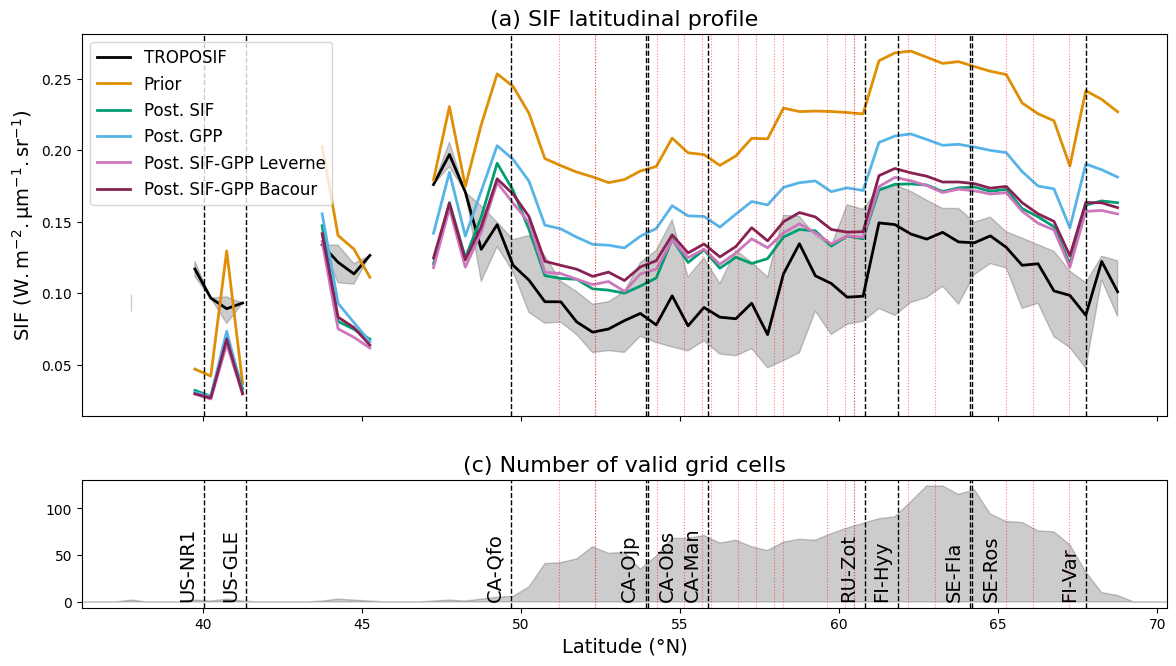

In [21]:
#Plot
fontsize_title=16
fontsize_label=14
fontsize_legend=12

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(14,7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
ax.fill_between(obs.lat.values, obs_q1.values, obs_q3.values,
    alpha=0.2, edgecolor='black', facecolor='black')
ax.plot(obs.lat.values, obs.values, label="TROPOSIF", color='black', linewidth=2)
ax.plot(bacour.lat.values, bacour.values, label="Prior",color=sns.color_palette("colorblind")[1], linewidth=2)
ax.plot(optsif.lat.values, optsif.values, label="Post. SIF",color=sns.color_palette("colorblind")[2], linewidth=2)
ax.plot(optgpp.lat.values, optgpp.values, label="Post. GPP",color=sns.color_palette("colorblind")[-1], linewidth=2)
ax.plot(raczka.lat.values, raczka.values, label="Post. SIF-GPP Leverne",color=sns.color_palette("colorblind")[4], linewidth=2)
ax.plot(bacouropt.lat.values, bacouropt.values, label="Post. SIF-GPP Bacour",color=ibm_colors[13], linewidth=2)

# Add vertical lines with labels
for i in filtered_data_assimilation.index:
    ax.axvline(x=filtered_data_assimilation.lat[i], color='black', linestyle='--', linewidth=1)  # Add the vertical line

# Add vertical lines for grid cells
for i in assim_pixels.index:
    ax.axvline(x=assim_pixels.latitude[i], color='red', linestyle=':', linewidth=0.8, alpha=0.5)  # Add the vertical line

ax.set_title('(a) SIF latitudinal profile',fontsize=fontsize_title)
ax.set_ylabel('SIF ($\mathrm{W.m^{-2}.\mu m^{-1}.sr^{-1}}$)',fontsize=fontsize_label)
ax.set_xlabel('',fontsize=fontsize_label)
ax.legend(fontsize=fontsize_legend)

# Plot the number of points used
# Manually set the x-axis limits for ax2
ax2.set_xlim(ax.get_xlim())
ax2.fill_between(non_null_count.lat.values, 0, non_null_count.values, alpha=0.2, edgecolor='black', facecolor='black')
ax2.set_title('(c) Number of valid grid cells',fontsize=fontsize_title)
ax2.set_xlabel('Latitude (°N)',fontsize=fontsize_label)

# Add vertical lines for grid cells
for i in assim_pixels.index:
    ax2.axvline(x=assim_pixels.latitude[i], color='red', linestyle=':', linewidth=0.8, alpha=0.5)  # Add the vertical line

for i in filtered_data_assimilation.index:
    ax2.axvline(x=filtered_data_assimilation.lat[i], color='black', linestyle='--', linewidth=1)  # Add the vertical line
    if (filtered_data_assimilation.id[i]=='CA-Obs') | (filtered_data_assimilation.id[i]=='SE-Ros'):
        ax2.text(filtered_data_assimilation.lat[i]+0.6, 5, filtered_data_assimilation.id[i], rotation='vertical', ha='center', fontsize=fontsize_label)  #
    else:
        ax2.text(filtered_data_assimilation.lat[i]-0.5, 5, filtered_data_assimilation.id[i], rotation='vertical', ha='center', fontsize=fontsize_label)  #

fig.subplots_adjust(hspace=0.25,top=0.92,bottom=0.1)
plt.show(block=False)
#plt.savefig('PNG/Figure5ac.png', format='png',dpi=300, bbox_inches='tight')